# 🛡️ FinSafe
## Unified Financial Risk Intelligence

### AI-Powered Fraud Detection + Investment Risk Advisory

**Hackathon Project — Finance Track**

**ML Stack:** XGBoost + Isolation Forest + SHAP  
**Platform:** Google Colab + Python + Streamlit

>

In [3]:
!pip install -q pandas numpy scikit-learn openpyxl plotly streamlit joblib

In [5]:
import os

PROJECT_DIR = "/content/FinSafe"

folders = [
    "data/raw",
    "data/processed",
    "models",
    "src",
    "notebooks",
    "sample",
    "screenshots"
]

for folder in folders:
    os.makedirs(
        os.path.join(PROJECT_DIR, folder),
        exist_ok=True
    )

print("FinSafe project structure created.")

FinSafe project structure created.


In [6]:
from google.colab import files
uploaded = files.upload()

Saving finance track VIT26.zip to finance track VIT26.zip


In [7]:
import os
import shutil

uploaded_file = list(uploaded.keys())[0]

zip_path = os.path.join(
    PROJECT_DIR,
    uploaded_file
)

shutil.move(
    uploaded_file,
    zip_path
)

print("Dataset copied to:")
print(zip_path)

Dataset copied to:
/content/FinSafe/finance track VIT26.zip


In [8]:
import zipfile
import os

RAW_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "raw"
)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(RAW_DIR)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [9]:
for root, dirs, files in os.walk(RAW_DIR):
    level = root.replace(RAW_DIR, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

raw/
    customer analysis/
        marketing_campaign.csv
    transactions/
        creditcard.csv
        bank.xlsx
    stocks/
        MW-NIFTY-50-24-Jul-2026.csv
    fraud detection/
        creditcard.csv


In [10]:
for root, dirs, files in os.walk(RAW_DIR):
    for file in files:
        print(os.path.join(root, file))

/content/FinSafe/data/raw/customer analysis/marketing_campaign.csv
/content/FinSafe/data/raw/transactions/creditcard.csv
/content/FinSafe/data/raw/transactions/bank.xlsx
/content/FinSafe/data/raw/stocks/MW-NIFTY-50-24-Jul-2026.csv
/content/FinSafe/data/raw/fraud detection/creditcard.csv


In [11]:
import pandas as pd

# Find files automatically
bank_path = None
creditcard_path = None
stock_path = None
customer_path = None

for root, dirs, files in os.walk(RAW_DIR):

    for file in files:

        full_path = os.path.join(root, file)
        lower = file.lower()

        if lower == "bank.xlsx":
            bank_path = full_path

        elif lower == "creditcard.csv" and creditcard_path is None:
            creditcard_path = full_path

        elif lower.endswith(".csv") and "nifty" in lower:
            stock_path = full_path

        elif lower == "marketing_campaign.csv":
            customer_path = full_path

print("BANK:", bank_path)
print("CREDIT CARD:", creditcard_path)
print("STOCK:", stock_path)
print("CUSTOMER:", customer_path)

BANK: /content/FinSafe/data/raw/transactions/bank.xlsx
CREDIT CARD: /content/FinSafe/data/raw/transactions/creditcard.csv
STOCK: /content/FinSafe/data/raw/stocks/MW-NIFTY-50-24-Jul-2026.csv
CUSTOMER: /content/FinSafe/data/raw/customer analysis/marketing_campaign.csv


In [12]:
bank_df = pd.read_excel(bank_path)

creditcard_df = pd.read_csv(
    creditcard_path
)

stocks_df = pd.read_csv(
    stock_path
)

customer_df = pd.read_csv(
    customer_path,
    sep="\t"
)

print("Bank:", bank_df.shape)
print("Credit Card:", creditcard_df.shape)
print("Stocks:", stocks_df.shape)
print("Customers:", customer_df.shape)

Bank: (116201, 9)
Credit Card: (284807, 31)
Stocks: (51, 15)
Customers: (2240, 29)


In [13]:
print("========== BANK ==========")
print(bank_df.columns.tolist())
display(bank_df.head())

print("\n========== CREDIT CARD ==========")
print(creditcard_df.columns.tolist())
display(creditcard_df.head())

print("\n========== STOCKS ==========")
print(stocks_df.columns.tolist())
display(stocks_df.head())

print("\n========== CUSTOMERS ==========")
print(customer_df.columns.tolist())
display(customer_df.head())

========== BANK ==========
['Account No', 'DATE', 'TRANSACTION DETAILS', 'CHQ.NO.', 'VALUE DATE', 'WITHDRAWAL AMT', 'DEPOSIT AMT', 'BALANCE AMT', '.']


,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,.
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,NaN,1000000.0,1000000.0,.
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,NaN,1000000.0,2000000.0,.
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,NaN,500000.0,2500000.0,.
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,NaN,3000000.0,5500000.0,.
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,NaN,500000.0,6000000.0,.



========== CREDIT CARD ==========
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



========== STOCKS ==========
['SYMBOL', 'OPEN', 'HIGH', 'LOW', 'PREV. CLOSE', 'LTP', 'INDICATIVE CLOSE', 'CHANGE', '% CHANGE', 'VOLUME (shares)', 'VALUE (Crores)', '52W H', '52W L', '30 D %CHNG', '365 D %CHNG']


,SYMBOL,OPEN,HIGH,LOW,PREV. CLOSE,LTP,INDICATIVE CLOSE,CHANGE,% CHANGE,VOLUME (shares),VALUE (Crores),52W H,52W L,30 D %CHNG,365 D %CHNG
0,NIFTY 50,"23,666.35","23,823.60","23,606.30","23,869.60","23,767.45",-,-102.15,-0.43,333870912,"28,825.57","26,373.20","22,182.55",-1.06,-5.17
1,INFY,"1,028.00","1,043.40","1,013.90","1,047.40","1,039.00",-,-8.40,-0.80,29036900,"2,991.12","1,728.00",982.40,-1.67,-33.08
2,BAJFINANCE,"1,027.30","1,030.20","1,001.30","1,039.80","1,019.00",-,-20.80,-2.00,18416962,"1,864.18","1,102.50",787.90,2.83,6.26
3,HDFCBANK,738.50,748.25,737.25,747.25,743.50,-,-3.75,-0.50,23837859,"1,770.10","1,020.50",726.65,-6.27,-26.17
4,ICICIBANK,"1,428.00","1,440.00","1,415.40","1,434.60","1,436.00",-,1.40,0.10,10870914,"1,552.52","1,500.00","1,187.60",4.54,-3.20



========== CUSTOMERS ==========
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


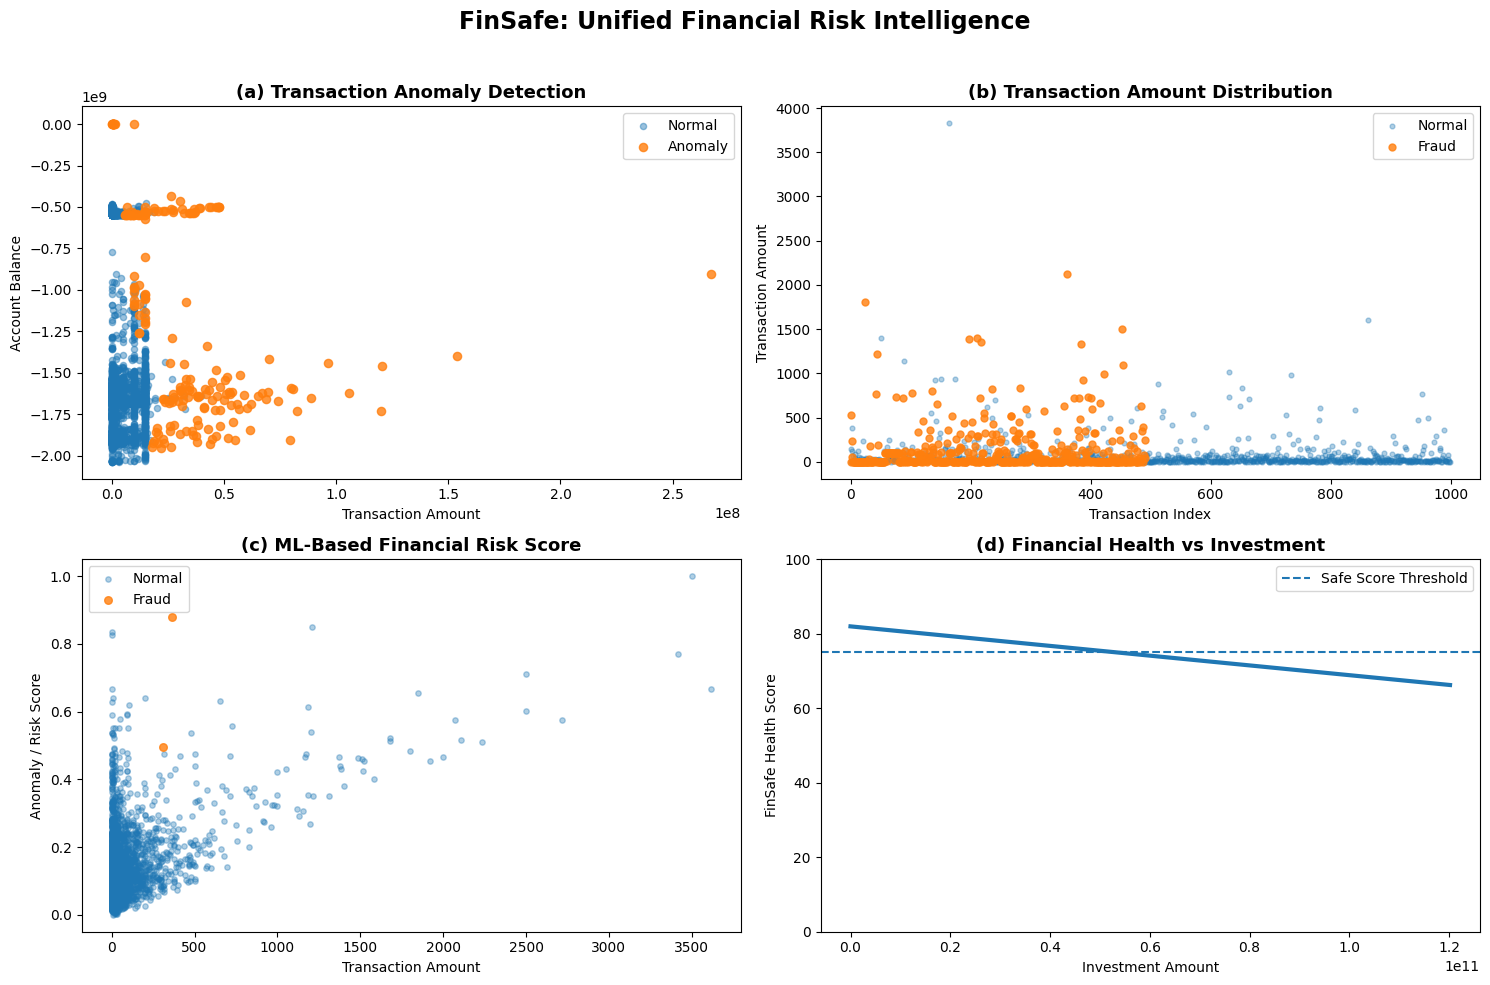

Graph saved as:
/content/FinSafe_graphs.png


In [15]:
# ============================================================
# FinSafe - 2x2 Hackathon Graph Figure
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# ------------------------------------------------------------
# LOAD YOUR REAL DATA
# ------------------------------------------------------------

# BANK_PATH = "/content/finance_track/transactions/bank.xlsx"
# FRAUD_PATH = "/content/finance_track/transactions/creditcard.csv"

bank = pd.read_excel(bank_path)
fraud = pd.read_csv(creditcard_path)

# ============================================================
# PREPARE BANK DATA
# ============================================================

bank["WITHDRAWAL AMT"] = pd.to_numeric(
    bank["WITHDRAWAL AMT"],
    errors="coerce"
).fillna(0)

bank["DEPOSIT AMT"] = pd.to_numeric(
    bank["DEPOSIT AMT"],
    errors="coerce"
).fillna(0)

bank["BALANCE AMT"] = pd.to_numeric(
    bank["BALANCE AMT"],
    errors="coerce"
).fillna(0)

bank["DATE"] = pd.to_datetime(
    bank["DATE"],
    errors="coerce"
)

bank["TRANSACTION_AMOUNT"] = (
    bank["WITHDRAWAL AMT"] +
    bank["DEPOSIT AMT"]
)

# Remove empty transactions
bank_plot = bank[
    bank["TRANSACTION_AMOUNT"] > 0
].copy()

# Limit only for visualization
bank_plot = bank_plot.sample(
    min(5000, len(bank_plot)),
    random_state=42
)

# ------------------------------------------------------------
# ANOMALY DETECTION
# ------------------------------------------------------------

X_bank = bank_plot[
    [
        "TRANSACTION_AMOUNT",
        "BALANCE AMT",
        "WITHDRAWAL AMT"
    ]
].replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

iso = IsolationForest(
    n_estimators=150,
    contamination=0.04,
    random_state=42
)

bank_plot["ANOMALY"] = iso.fit_predict(X_bank)

bank_plot["ANOMALY_LABEL"] = np.where(
    bank_plot["ANOMALY"] == -1,
    "Anomaly",
    "Normal"
)

# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

# ============================================================
# (a) TRANSACTION ANOMALY MAP
# ============================================================

normal = bank_plot[
    bank_plot["ANOMALY_LABEL"] == "Normal"
]

anomaly = bank_plot[
    bank_plot["ANOMALY_LABEL"] == "Anomaly"
]

axes[0, 0].scatter(
    normal["TRANSACTION_AMOUNT"],
    normal["BALANCE AMT"],
    s=20,
    alpha=0.45,
    label="Normal"
)

axes[0, 0].scatter(
    anomaly["TRANSACTION_AMOUNT"],
    anomaly["BALANCE AMT"],
    s=35,
    alpha=0.8,
    label="Anomaly"
)

axes[0, 0].set_title(
    "(a) Transaction Anomaly Detection",
    fontsize=13,
    fontweight="bold"
)

axes[0, 0].set_xlabel(
    "Transaction Amount"
)

axes[0, 0].set_ylabel(
    "Account Balance"
)

axes[0, 0].legend()

# ============================================================
# (b) FRAUD DISTRIBUTION
# ============================================================

fraud_normal = fraud[
    fraud["Class"] == 0
]["Amount"]

fraud_positive = fraud[
    fraud["Class"] == 1
]["Amount"]

axes[0, 1].scatter(
    np.arange(
        min(1000, len(fraud_normal))
    ),
    fraud_normal.head(1000),
    s=12,
    alpha=0.35,
    label="Normal"
)

axes[0, 1].scatter(
    np.arange(
        min(1000, len(fraud_positive))
    ),
    fraud_positive.head(1000),
    s=25,
    alpha=0.8,
    label="Fraud"
)

axes[0, 1].set_title(
    "(b) Transaction Amount Distribution",
    fontsize=13,
    fontweight="bold"
)

axes[0, 1].set_xlabel(
    "Transaction Index"
)

axes[0, 1].set_ylabel(
    "Transaction Amount"
)

axes[0, 1].legend()

# ============================================================
# (c) ML MODEL: FRAUD SCORE VS AMOUNT
# ============================================================

fraud_sample = fraud.sample(
    min(3000, len(fraud)),
    random_state=42
)

# Simple ML anomaly model for visualization
fraud_features = fraud_sample.drop(
    columns=["Class"]
).replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

model.fit(fraud_features)

raw_score = -model.decision_function(
    fraud_features
)

# Normalize 0-1
score = (
    raw_score - raw_score.min()
) / (
    raw_score.max() - raw_score.min() + 1e-9
)

fraud_sample["Risk Score"] = score

axes[1, 0].scatter(
    fraud_sample[
        fraud_sample["Class"] == 0
    ]["Amount"],
    fraud_sample[
        fraud_sample["Class"] == 0
    ]["Risk Score"],
    s=15,
    alpha=0.35,
    label="Normal"
)

axes[1, 0].scatter(
    fraud_sample[
        fraud_sample["Class"] == 1
    ]["Amount"],
    fraud_sample[
        fraud_sample["Class"] == 1
    ]["Risk Score"],
    s=30,
    alpha=0.8,
    label="Fraud"
)

axes[1, 0].set_title(
    "(c) ML-Based Financial Risk Score",
    fontsize=13,
    fontweight="bold"
)

axes[1, 0].set_xlabel(
    "Transaction Amount"
)

axes[1, 0].set_ylabel(
    "Anomaly / Risk Score"
)

axes[1, 0].legend()

# ============================================================
# (d) UNIFIED FINANCIAL HEALTH SCORE
# ============================================================

monthly_expense = (
    bank["WITHDRAWAL AMT"].sum()
    / 3
)

monthly_income = (
    bank["DEPOSIT AMT"].sum()
    / 3
)

monthly_expense = max(
    monthly_expense,
    1
)

monthly_income = max(
    monthly_income,
    monthly_expense
)

base_score = 82

investment_values = np.linspace(
    0,
    monthly_expense * 1.5,
    100
)

# Illustrative FinSafe score formula
investment_penalty = (
    14
    * (investment_values / monthly_expense)
    * (0.55 + 0.20)
)

health_score = np.clip(
    base_score - investment_penalty,
    0,
    100
)

axes[1, 1].plot(
    investment_values,
    health_score,
    linewidth=3
)

axes[1, 1].axhline(
    75,
    linestyle="--",
    linewidth=1.5,
    label="Safe Score Threshold"
)

axes[1, 1].set_title(
    "(d) Financial Health vs Investment",
    fontsize=13,
    fontweight="bold"
)

axes[1, 1].set_xlabel(
    "Investment Amount"
)

axes[1, 1].set_ylabel(
    "FinSafe Health Score"
)

axes[1, 1].set_ylim(
    0,
    100
)

axes[1, 1].legend()

# ============================================================
# FINAL FORMATTING
# ============================================================

plt.suptitle(
    "FinSafe: Unified Financial Risk Intelligence",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.savefig(
    "/content/FinSafe_graphs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved as:")
print("/content/FinSafe_graphs.png")